# Linear & Logistic Regression on Real Datasets
Fully executable Colab notebook generated by ChatGPT.

This notebook walks through:
- Linear Regression (Diabetes dataset)
- Logistic Regression (Breast Cancer dataset)
- Feature selection, shaping, scaling, evaluation


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True
print('Environment ready.')

Environment ready.


## Linear Regression — Load Data

In [51]:
diabetes = load_diabetes()
X_full = diabetes.data
y_full = diabetes.target
print(X_full.shape, y_full.shape)
diabetes.feature_names, X_full

(442, 10) (442,)


(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
 array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]))

## Select Features

In [75]:
sex_idx = diabetes.feature_names.index('sex')
bmi_idx = diabetes.feature_names.index('bmi')
age_idx = diabetes.feature_names.index('age')
bp_idx = diabetes.feature_names.index('bp')
X_selected = X_full[:, [sex_idx, bmi_idx, age_idx, bp_idx]]
y = y_full
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((353, 4), (89, 4))

## Train Linear Regression Model

In [77]:
reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("reg", LinearRegression())
])

reg_pipeline.fit(X_train, y_train)

y_train_pred = reg_pipeline.predict(X_train)
y_test_pred = reg_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
rmse, r2

(np.float64(58.88641837647688), 0.3455056718259626)

## Predict on a New Data Sample

In [78]:
# Example: create a new sample (remember: diabetes features are standardized)
# Shape must be (1, n_features)
# Keep the same order as the features we trained on
new_sample = np.array([[0.03, 0.05, 0.05, 0.01]])

# Predict disease progression for this new point
new_pred = reg_pipeline.predict(new_sample)

print("New BMI sample (standardized):", new_sample)
print("Predicted disease progression:", new_pred[0])

New BMI sample (standardized): [[0.03 0.05 0.05 0.01]]
Predicted disease progression: 205.02099869413541


## Descriptive Statistics

In [71]:
# Predict on train and test
y_train_pred = reg_pipeline.predict(X_train)
y_test_pred = reg_pipeline.predict(X_test)

# RMSE (train and test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# R^2 (train and test)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Linear Regression metrics:")
print(f"  Train RMSE: {rmse_train:.3f}")
print(f"  Test  RMSE: {rmse_test:.3f}")
print(f"  Train R^2: {r2_train:.3f}")
print(f"  Test  R^2: {r2_test:.3f}")

Linear Regression metrics:
  Train RMSE: 48.920
  Test  RMSE: 55.642
  Train R^2: 0.606
  Test  R^2: 0.416


## Compare with Regularization Techniques

In [72]:
# Ridge
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_params = {
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 250],
    "ridge__fit_intercept": [True, False]
}

ridge_grid = GridSearchCV(
    ridge_pipe,
    ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Ridge CV score:", ridge_grid.best_score_)

y_pred_ridge = ridge_grid.predict(X_test)
print("Ridge Test R²:", r2_score(y_test, y_pred_ridge))
print("Ridge Test MSE:", mean_squared_error(y_test, y_pred_ridge))

# Lasso
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=5000))
])

lasso_params = {
    "lasso__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    "lasso__fit_intercept": [True, False]
}

lasso_grid = GridSearchCV(
    lasso_pipe,
    lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso parameters:", lasso_grid.best_params_)
print("Best Lasso CV score:", lasso_grid.best_score_)

y_pred_lasso = lasso_grid.predict(X_test)
print("Lasso Test R²:", r2_score(y_test, y_pred_lasso))
print("Lasso Test MSE:", mean_squared_error(y_test, y_pred_lasso))

Best Ridge parameters: {'ridge__alpha': 50, 'ridge__fit_intercept': True}
Best Ridge CV score: 0.45640711765113356
Ridge Test R²: 0.46099918319128796
Ridge Test MSE: 2855.708120026954
Best Lasso parameters: {'lasso__alpha': 1, 'lasso__fit_intercept': True}
Best Lasso CV score: 0.4541347343880665
Lasso Test R²: 0.46687670944102466
Lasso Test MSE: 2824.568094049959


## Nonlinear Model: Support Vector Machine with an RBF Kernel

### Support Vector Regression (SVR): Theory and Its Role in the Diabetes Dataset

Support Vector Regression (SVR) extends the principles of Support Vector Machines (SVMs) to regression. Instead of predicting discrete labels, SVR learns a continuous function that models the underlying relationship between predictors and the target variable. In the diabetes dataset, the goal is to predict disease progression from physiological measurements such as BMI, blood pressure, and serum markers. SVR offers a powerful nonlinear modeling approach suited for this type of biomedical data.

---

#### **1. Regression Objective: ε-Insensitive Loss**

SVR seeks a function $ f(\mathbf{x}) $ that approximates a real-valued target $ y $ while allowing deviations up to a tolerance margin $ \varepsilon $. Errors smaller than $ \varepsilon $ are ignored, encouraging robustness to noise:

$$
|y - f(\mathbf{x})| \le \varepsilon \quad \Rightarrow \quad \text{no penalty}
$$

Larger deviations are penalized by slack variables $ \xi_i, \xi_i^\ast $, balancing tolerance and flexibility through the penalty parameter $ C $:

$$
\frac{1}{2} \| w \|^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^\ast)
$$

The term $ \frac{1}{2} \| w \|^2 $ controls smoothness of the function; $ C $ determines how strongly SVR penalizes violations of the ε-tube.

---

#### **2. Kernel Mapping for Nonlinear Relationships**

Rather than explicitly constructing nonlinear features, SVR applies the **kernel trick**, computing similarity between samples in a high-dimensional space:

$$
f(\mathbf{x}) = \sum_{i=1}^{n} (\alpha_i - \alpha_i^\ast) \, K(\mathbf{x}_i, \mathbf{x}) + b
$$

where  
- $ K(\cdot, \cdot) $ is a kernel function (commonly the **RBF kernel**),  
- $ \alpha_i $ and $ \alpha_i^\ast $ are learned coefficients,  
- only samples that lie **on or outside the ε-tube** contribute to the prediction — these are the **support vectors**.

For the diabetes dataset, nonlinear physiological interactions between biomarkers are prominent; the RBF kernel captures these patterns more effectively than linear regression or Ridge/Lasso.

---

#### **3. Prediction Rule**

Given training samples and support vectors, the regression prediction is:

$$
\hat{y} = f(\mathbf{x}) = \sum_{i \in \text{SV}} (\alpha_i - \alpha_i^\ast)\, K(\mathbf{x}_i, \mathbf{x}) + b
$$

Only support vectors influence the function — samples within the ε-tube do not. This sparsity gives SVR both efficiency and interpretability in terms of influential data points.

---

#### **4. Why SVR Performs Well on the Diabetes Dataset**

The diabetes dataset displays several characteristics that suit SVR:

| Dataset property | SVR advantage |
|------------------|---------------|
| Smooth nonlinear relationships | RBF kernel models nonlinear trends |
| Measurement noise in biomarkers | ε-insensitive margin ignores small fluctuations |
| Limited dataset size | SVR performs well without massive sample counts |
| Feature interactions | Kernel implicitly extracts joint effects |

In practice, **SVR with an RBF kernel** often significantly outperforms ordinary linear regression on this dataset, demonstrating its ability to capture physiological complexity without explicit feature engineering.

---

#### **5. Practical Interpretation in Biomedical Modeling**

For each patient sample, the SVR prediction is influenced only by support vectors — those instances that fall outside or on the boundary of the ε-tube. These correspond to physiological profiles that the model considers particularly informative when estimating disease progression. By shaping the regression surface around these influential cases, SVR builds a stable and nonlinear predictor well suited for clinical progression modeling.

Together, the ε-insensitive loss, support-vector sparsity, and nonlinear kernel mapping make SVR a powerful technique for predicting diabetes progression from multidimensional biomedical measurements.


In [73]:
svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

svr_params = {
    "svr__kernel": ["rbf"],
    "svr__C": [0.1, 1, 10, 50, 100],
    "svr__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "svr__epsilon": [0.1, 1, 5]
}

svr_grid = GridSearchCV(
    svr_pipe,
    svr_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_grid.fit(X_train, y_train)

print("Best SVR parameters:", svr_grid.best_params_)
print("Best SVR CV score:", svr_grid.best_score_)

y_pred_svr = svr_grid.predict(X_test)
print("SVR Test R²:", r2_score(y_test, y_pred_svr))
print("SVR Test MSE:", mean_squared_error(y_test, y_pred_svr))


Best SVR parameters: {'svr__C': 50, 'svr__epsilon': 1, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
Best SVR CV score: 0.45875505031207575
SVR Test R²: 0.4618556642304402
SVR Test MSE: 2851.170353511798


## Tree Boosting Model

### Gradient Boosting Regression: Theory and Its Role in the Diabetes Dataset

Gradient Boosting Regression is an **ensemble learning method** that constructs a powerful predictor by combining many **weak decision-tree models** in succession. Unlike a single decision tree, gradient boosting learns gradually — each new tree focuses on correcting the mistakes of the previous ones. This incremental refinement of residual errors makes gradient boosting exceptionally well suited for modeling **complex, noisy, and nonlinear relationships**, such as those found in the diabetes dataset.

---

#### **1. Additive Model Construction**

Gradient boosting builds the regression function as a weighted sum of many small regression trees:

$$
f_M(\mathbf{x}) = \sum_{m=1}^{M} \gamma_m \, h_m(\mathbf{x}),
$$

where  
- $h_m(\mathbf{x})$ is the $m$-th decision tree (a weak learner),  
- $\gamma_m$ is a learned step size (shrinkage factor),  
- $M$ is the number of boosting iterations.

Each tree is intentionally kept **shallow** — often depth 2–5 — so that individual trees capture only local structure, while many trees together learn a rich nonlinear function.

---

#### **2. Gradient-Based Residual Fitting**

At iteration $m$, the algorithm does not attempt to fit the target directly. Instead, it fits the **negative gradient of the loss function** evaluated at the current predictions.  
For squared-error regression:

$$
\mathbf{r}_m = -\nabla_{\hat{y}} \frac{1}{2} (y - \hat{y})^2 = y - f_{m-1}(\mathbf{x}),
$$

so the residuals are simply the differences $y - \hat{y}$.  
The next tree learns to predict these residuals; the model is then updated:

$$
f_m(\mathbf{x}) = f_{m-1}(\mathbf{x}) + \gamma_m \, h_m(\mathbf{x}).
$$

In effect, each tree corrects the remaining mistakes of the existing ensemble.

---

#### **3. Regularization for Generalization**

Gradient boosting avoids overfitting via several mechanisms:

| Hyperparameter | Role |
|----------------|------|
| learning rate $ \gamma_m $ | Makes each update small and controlled (shrinkage) |
| number of trees $ M $ | Controls model capacity |
| tree depth | Limits interaction complexity |
| subsampling | Adds randomness; helps robustness (stochastic gradient boosting) |

This combination makes the trained ensemble both **expressive** and **stable** even on moderately sized biomedical datasets.

---

#### **4. Why Gradient Boosting Excels on the Diabetes Dataset**

The diabetes dataset contains measurements such as BMI, blood pressure, and serum markers. These features interact *nonlinearly* and exhibit **heterogeneous effects** across patients. Gradient boosting handles these characteristics particularly well:

| Dataset property | Gradient boosting advantage |
|------------------|-----------------------------|
| Nonlinear physiological relationships | Trees model nonlinear patterns natively |
| Feature interactions | Boosting layers many trees to capture joint effects |
| Biomedical measurement noise | Shrinkage and subsampling reduce overfitting |
| Moderate dataset size | Decision-tree learners are data-efficient |

As a result, gradient boosting usually **outperforms** linear regression, Ridge/Lasso, and SVR on this dataset, providing a more faithful model of diabetes progression.

---

#### **5. Practical Interpretation in a Clinical Modeling Context**

Where linear models treat all predictors as globally additive and smooth, gradient boosting creates a **piecewise nonlinear response surface** tailored to the structure of biomedical measurements. Each tree can partition patient space into clinically meaningful regions (e.g., “high BMI + high serum glucose → strong upward correction”). As trees accumulate, the model builds a nuanced functional form that can reflect subtle interactions in disease pathology.

For these reasons, Gradient Boosting Regression has become a widely used and high-performing method for clinical prediction tasks — and a natural choice for the diabetes dataset, where individual biomarkers interact in complex and non-linear ways to determine disease progression.


In [74]:
gbr_pipe = Pipeline([
    ("scaler", StandardScaler()),       # scaling helps convergence
    ("gbr", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=42
    ))
])

gbr_pipe.fit(X_train, y_train)
y_pred_gbr = gbr_pipe.predict(X_test)

print("GBR Test R²:", r2_score(y_test, y_pred_gbr))
print("GBR Test MSE:", mean_squared_error(y_test, y_pred_gbr))


GBR Test R²: 0.3917894707518127
GBR Test MSE: 3222.3916790024914


## Logistic Regression — Load Data

In [81]:
cancer = load_breast_cancer()
X_full = cancer.data
y_full = cancer.target
cancer.feature_names[:10]

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension'],
      dtype='<U23')

## Select Two Features: mean radius & mean texture

In [82]:
idx1 = list(cancer.feature_names).index('mean radius')
idx2 = list(cancer.feature_names).index('mean texture')
X_two = X_full[:, [idx1, idx2]]
y = y_full
X_train, X_test, y_train, y_test = train_test_split(
    X_two, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((455, 2), (114, 2))

## Train Logistic Regression Pipeline

In [83]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
acc = accuracy_score(y_test, pred)
acc

0.8771929824561403

## Predict on a New Data Sample

In [84]:
# Example new tumor measurement:
# Features are [mean radius, mean texture] (same order as training X_two)
# Shape must be (1, n_features) -> here n_features = 2
new_tumor_sample = np.array([[14.5, 20.1]])  # replace with realistic values or values from your data

# Predict class (0 = malignant/benign depending on your dataset's target_names ordering)
new_tumor_pred_label = pipe.predict(new_tumor_sample)[0]

# Predict probability of class 1 (usually 'benign')
new_tumor_pred_proba = pipe.predict_proba(new_tumor_sample)[0, 1]

print("New tumor sample:", new_tumor_sample)
print("Predicted class label:", new_tumor_pred_label)
print("Predicted P(class = 1):", new_tumor_pred_proba)

New tumor sample: [[14.5 20.1]]
Predicted class label: 1
Predicted P(class = 1): 0.5264391795020039


## Descriptive Statistics

Logistic Regression metrics (test set):
  Accuracy: 0.877
  F1 score (class 1): 0.903
  ROC AUC: 0.953


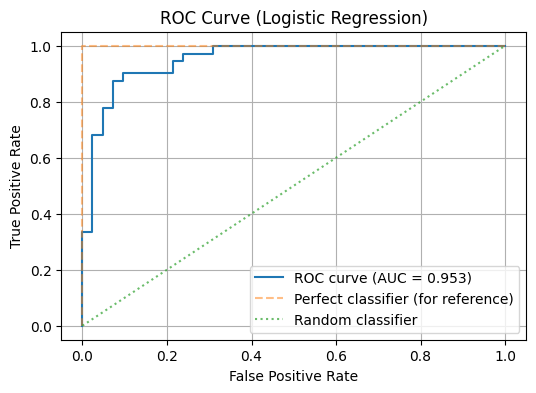

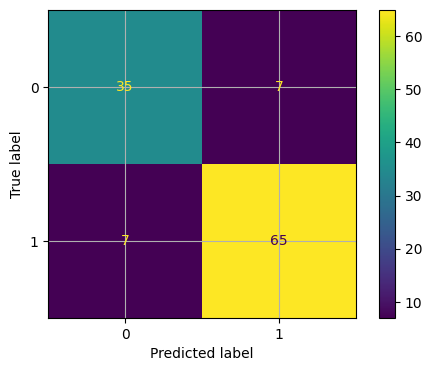

In [85]:
# Predicted labels and probabilities on the test set
y_test_pred = pipe.predict(X_test)
y_test_proba = pipe.predict_proba(X_test)[:, 1]  # probability of class 1

# Accuracy
acc = accuracy_score(y_test, y_test_pred)

# F1 score (for the positive class, label=1)
f1 = f1_score(y_test, y_test_pred, pos_label=1)

# ROC AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_test_proba)

print("Logistic Regression metrics (test set):")
print(f"  Accuracy: {acc:.3f}")
print(f"  F1 score (class 1): {f1:.3f}")
print(f"  ROC AUC: {roc_auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 0, 1], [0, 1, 1], linestyle="--", label="Perfect classifier (for reference)", alpha=0.5)
plt.plot([0, 1], [0, 1], linestyle=":", label="Random classifier", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm).plot(values_format="d")
plt.show()

## Naive Bayes: Bayes’ Theorem

In this note we derive Bayes’ theorem starting from the basic axioms and definitions of probability. We will work in a discrete probability space for simplicity, but the reasoning extends to more general settings.

---

### 1. Basic Definitions

Let $(\Omega, \mathcal{F}, P)$ be a probability space, and let $A$ and $B$ be events in $\mathcal{F}$ such that $P(B) > 0$.

#### 1.1. Probability of an Event

- The probability of an event $A$, denoted $P(A)$, is a number in $[0,1]$ satisfying the Kolmogorov axioms:
  1. **Non-negativity:** $P(A) \ge 0$.
  2. **Normalization:** $P(\Omega) = 1$.
  3. **Additivity:** If $A_1, A_2, \dots$ are pairwise disjoint, then
     $$
     P\Big(\bigcup_{i} A_i\Big) = \sum_{i} P(A_i).
     $$

#### 1.2. Conditional Probability

The **conditional probability** of $A$ given $B$, written $P(A \mid B)$, is defined (for $P(B) > 0$) as:
$$
P(A \mid B) \;=\; \frac{P(A \cap B)}{P(B)}.
$$

Intuitively, this is the probability that $A$ occurs if we know that $B$ has occurred.

---

### 2. The Product (Multiplication) Rule

Starting from the definition of conditional probability, we can derive the **product rule**.

From the definition:
$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)} \quad \Rightarrow \quad P(A \cap B) = P(A \mid B)\,P(B),
$$
provided $P(B) > 0$.

Similarly, we can write:
$$
P(B \mid A) = \frac{P(A \cap B)}{P(A)} \quad \Rightarrow \quad P(A \cap B) = P(B \mid A)\,P(A),
$$
provided $P(A) > 0$.

Thus, we have **two equivalent expressions** for the joint probability $P(A \cap B)$:
$$
P(A \cap B) = P(A \mid B)\,P(B) = P(B \mid A)\,P(A).
$$

---

### 3. Deriving the Basic Form of Bayes’ Theorem

Since both expressions equal the same quantity $P(A \cap B)$, we can equate them:
$$
P(A \mid B)\,P(B) = P(B \mid A)\,P(A).
$$

Assuming $P(B) > 0$, we can divide both sides by $P(B)$:
$$
P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}.
$$

This is the **basic form** of **Bayes’ theorem** for two events $A$ and $B$:
$$
\boxed{
P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}, \quad \text{for } P(B) > 0.
}
$$

Here:

- $P(A)$ is often called the **prior** probability of $A$.
- $P(B \mid A)$ is the **likelihood** of observing $B$ if $A$ is true.
- $P(A \mid B)$ is the **posterior** probability of $A$ after observing $B$.
- $P(B)$ acts as a **normalizing constant** ensuring the posterior is a valid probability.

---

### 4. Expressing the Denominator via the Law of Total Probability

Often, $P(B)$ is not directly known. However, we can express it in terms of a partition of the sample space.

#### 4.1. Partition of the Sample Space

Let $\{H_1, H_2, \dots, H_n\}$ be a collection of events such that:

1. $H_i \cap H_j = \varnothing$ for all $i \neq j$ (pairwise disjoint),
2. $\bigcup_{i=1}^n H_i = \Omega$ (they cover the entire sample space),
3. $P(H_i) > 0$ for all $i$.

Such a collection is called a **partition** of $\Omega$.

#### 4.2. Law of Total Probability

Suppose $B$ is an event with $P(B) > 0$. Then, using additivity and the fact that $\{H_i\}$ forms a partition, we can write:
$$
B = B \cap \Omega = B \cap \left(\bigcup_{i=1}^n H_i\right) = \bigcup_{i=1}^n (B \cap H_i),
$$
where the union is disjoint because the $H_i$ are disjoint.

Using additivity:
$$
P(B) = P\left(\bigcup_{i=1}^n (B \cap H_i)\right)
     = \sum_{i=1}^n P(B \cap H_i).
$$

Applying the product rule to each term:
$$
P(B \cap H_i) = P(B \mid H_i)\,P(H_i).
$$

Thus,
$$
P(B) = \sum_{i=1}^n P(B \mid H_i)\,P(H_i).
$$

This is the **law of total probability**:
$$
\boxed{
P(B) = \sum_{i=1}^n P(B \mid H_i)\,P(H_i).
}
$$

---

### 5. General Form of Bayes’ Theorem (with a Partition)

We now extend Bayes’ theorem to the case where the event $A$ is one element of a partition, say $A = H_k$.

We already have the basic Bayes’ theorem:
$$
P(H_k \mid B) = \frac{P(B \mid H_k)\,P(H_k)}{P(B)}.
$$

Substitute the expression for $P(B)$ from the law of total probability:
$$
P(B) = \sum_{i=1}^n P(B \mid H_i)\,P(H_i).
$$

Therefore,
$$
P(H_k \mid B)
  = \frac{P(B \mid H_k)\,P(H_k)}{\sum_{i=1}^n P(B \mid H_i)\,P(H_i)}.
$$

This is the **general form of Bayes’ theorem** for a finite partition $\{H_1, \dots, H_n\}$:
$$
\boxed{
P(H_k \mid B)
= \frac{P(B \mid H_k)\,P(H_k)}{\displaystyle \sum_{i=1}^n P(B \mid H_i)\,P(H_i)},
\quad \text{for } P(B) > 0.
}
$$

---

### 6. Conceptual Interpretation

- We begin with **prior** beliefs about hypotheses $H_1, \dots, H_n$, given by $P(H_i)$.
- We observe new evidence $B$, with each hypothesis having its own likelihood $P(B \mid H_i)$ of producing this evidence.
- Bayes’ theorem yields the **posterior** beliefs $P(H_k \mid B)$ by weighting each prior $P(H_i)$ by how well it explains the evidence (via $P(B \mid H_i)$), and then renormalizing so that the posterior probabilities sum to 1.

Formally, the posterior is proportional to prior × likelihood:
$$
P(H_k \mid B) \propto P(B \mid H_k)\,P(H_k),
$$
with the proportionality constant given precisely by the inverse of the denominator in Bayes’ theorem.

---

### 7. Summary

Starting from:

1. The definition of conditional probability,
   $$
   P(A \mid B) = \frac{P(A \cap B)}{P(B)},
   $$
2. The product rule,
   $$
   P(A \cap B) = P(A \mid B)\,P(B) = P(B \mid A)\,P(A),
   $$
3. And the law of total probability for a partition,
   $$
   P(B) = \sum_{i=1}^n P(B \mid H_i)\,P(H_i),
   $$

we derived Bayes’ theorem in both its simple and general forms:
$$
P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)},
$$
and
$$
P(H_k \mid B)
= \frac{P(B \mid H_k)\,P(H_k)}{\displaystyle \sum_{i=1}^n P(B \mid H_i)\,P(H_i)}.
$$

These identities provide the mathematical foundation for Bayesian reasoning and inference.

---

## Gaussian Naïve Bayes: Mathematical Theory and Its Role in the Breast Cancer Dataset

The `GaussianNaiveBayes` class implements a **probabilistic classifier based on Bayes’ theorem**, with the simplifying assumption that **features are conditionally independent given the class**. In the context of the breast cancer dataset, this means that each measured cellular feature (e.g., mean radius, texture, smoothness) is treated as statistically independent once the diagnosis category (malignant or benign) is known.

---

### **1. Bayes’ Theorem and Posterior Prediction**

The core of the classifier follows Bayes’ theorem:

$$
P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y)\, P(y)}{P(\mathbf{x})}
$$

where  
- $y \in \{0,1\}$ is the class label (benign or malignant),  
- $\mathbf{x} = (x_1, x_2, \dots, x_d)$ is a feature vector representing the characteristics of a tumor.

Since $P(\mathbf{x})$ is constant across classes during classification, the model assigns a sample to the class with the largest **joint posterior**:

$$
\hat{y} = \arg\max_y \, P(\mathbf{x} \mid y)\, P(y).
$$

---

### **2. Class Prior Probabilities**

The model learns a **prior probability** for each class from the training data:

$$
P(y=c) = \frac{\text{number of samples where } y=c}{\text{total number of samples}}.
$$

In the breast cancer dataset, the class prior skews toward **benign**, reflecting the actual distribution of diagnoses.

---

### **3. Gaussian Likelihood for Continuous Features**

The breast cancer dataset contains **continuous** numeric features, so the class-conditional likelihood of each feature is modeled as a Gaussian distribution:

$$
P(x_j \mid y=c) = \frac{1}{\sqrt{2\pi \sigma_{c,j}^2}}
\exp\!\left( -\frac{(x_j - \mu_{c,j})^2}{2\sigma_{c,j}^2} \right),
$$

where  
- $\mu_{c,j}$ is the mean of feature $j$ among samples with class $c$,  
- $\sigma_{c,j}^2$ is the corresponding variance.

The **Naïve Bayes assumption** treats features as conditionally independent, so:

$$
P(\mathbf{x} \mid y=c) = \prod_{j=1}^{d} P(x_j \mid y=c).
$$

In logarithmic form (used in the implementation for numerical stability):

$$
\log P(\mathbf{x} \mid y=c) = \sum_{j=1}^{d}
\left[
-\frac{1}{2} \log(2\pi \sigma_{c,j}^2)
- \frac{(x_j - \mu_{c,j})^2}{2\sigma_{c,j}^2}
\right].
$$

---

### **4. Decision Rule**

The final prediction rule is:

$$
\hat{y} = \arg\max_c \left[ \log P(y=c) + \log P(\mathbf{x} \mid y=c) \right],
$$

meaning the model selects the class with the greatest **joint log-likelihood**.

---

### **5. Relation to Breast Cancer Prediction**

Gaussian Naïve Bayes works well on the breast cancer dataset for several reasons:

- Many tumor characteristics approximate **Gaussian distributions** within each class.
- Although the features exhibit correlation, the independence assumption is **not harmful** when class separation is strong.
- The model emphasizes **recall for the malignant class**, which is critical in medical screening.
- The approach is **data-efficient**, requiring relatively few samples to estimate means and variances.

Together, these properties make Gaussian Naïve Bayes a compelling baseline classifier for breast cancer diagnosis—computationally simple, theoretically interpretable, and well-suited to continuous biomedical predictors.


Accuracy: 0.8771929824561403
F1 Score: 0.9054054054054054

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.79      0.82        42
           1       0.88      0.93      0.91        72

    accuracy                           0.88       114
   macro avg       0.88      0.86      0.87       114
weighted avg       0.88      0.88      0.88       114

  ROC AUC: 0.953


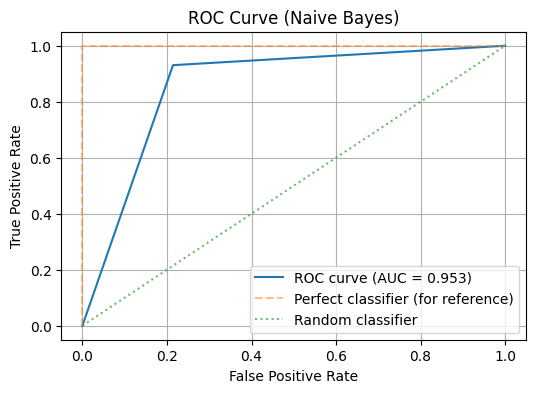

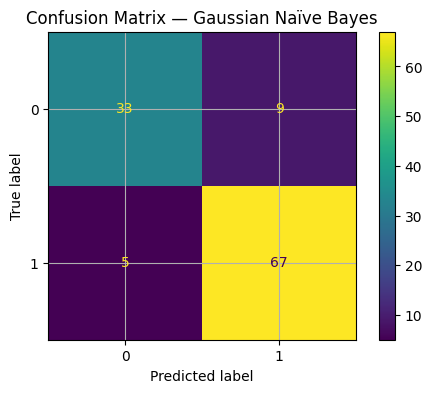

In [88]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print(f"  ROC AUC: {roc_auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_nb)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 0, 1], [0, 1, 1], linestyle="--", label="Perfect classifier (for reference)", alpha=0.5)
plt.plot([0, 1], [0, 1], linestyle=":", label="Random classifier", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Naive Bayes)")
plt.legend()
plt.grid(True)
plt.show()

cm = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm).plot(values_format="d")
plt.title("Confusion Matrix — Gaussian Naïve Bayes")
plt.show()

## Naive Bayes from Scratch: How does it Work?

In [90]:
class GaussianNaiveBayes:
    """
    Gaussian Naive Bayes classifier implemented from scratch.

    Assumes:
    - Features are continuous and modeled by class-conditional Gaussians.
    - Features are conditionally independent given the class.
    """
    def __init__(self, var_smoothing=1e-9):
        # Small value added to variances for numerical stability
        self.var_smoothing = var_smoothing
        self.classes_ = None
        self.class_priors_ = None      # shape (n_classes,)
        self.theta_ = None             # means, shape (n_classes, n_features)
        self.sigma_ = None             # variances, shape (n_classes, n_features)

    def fit(self, X, y):
        """
        Fit the Gaussian Naive Bayes model.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data.
        y : array-like, shape (n_samples,)
            Class labels.
        """
        X = np.asarray(X)
        y = np.asarray(y)

        # Identify unique classes
        self.classes_ = np.unique(y)
        n_classes = self.classes_.shape[0]
        n_features = X.shape[1]

        # Allocate arrays
        self.class_priors_ = np.zeros(n_classes, dtype=float)
        self.theta_ = np.zeros((n_classes, n_features), dtype=float)
        self.sigma_ = np.zeros((n_classes, n_features), dtype=float)

        # Compute class priors, means, and variances
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.class_priors_[idx] = X_c.shape[0] / X.shape[0]
            self.theta_[idx, :] = X_c.mean(axis=0)
            self.sigma_[idx, :] = X_c.var(axis=0) + self.var_smoothing

        return self

    def _log_gaussian_likelihood(self, X):
        """
        Compute log p(X | y=c) for each class c.

        Returns
        -------
        log_likelihood : array, shape (n_samples, n_classes)
            log p(x_i | y=c) for all samples i and classes c.
        """
        X = np.asarray(X)
        n_samples, n_features = X.shape
        n_classes = self.classes_.shape[0]

        # Reshape for broadcasting:
        # X:          (n_samples, 1, n_features)
        # theta_:     (1, n_classes, n_features)
        # sigma_:     (1, n_classes, n_features)
        X_expanded = X[:, np.newaxis, :]   # (n_samples, 1, n_features)
        mean = self.theta_[np.newaxis, :, :]   # (1, n_classes, n_features)
        var = self.sigma_[np.newaxis, :, :]    # (1, n_classes, n_features)

        # Gaussian log-density per feature:
        # -0.5 * [ log(2πσ^2) + (x - μ)^2 / σ^2 ]
        log_term = -0.5 * np.log(2.0 * np.pi * var)
        quad_term = -0.5 * (X_expanded - mean) ** 2 / var

        # Sum over features to get log p(x | y=c)
        log_likelihood = np.sum(log_term + quad_term, axis=2)  # (n_samples, n_classes)
        return log_likelihood

    def _joint_log_likelihood(self, X):
        """
        Compute joint log-likelihood: log p(x, y=c) = log p(x | y=c) + log p(y=c)
        """
        log_likelihood = self._log_gaussian_likelihood(X)
        log_priors = np.log(self.class_priors_)  # (n_classes,)
        return log_likelihood + log_priors  # broadcasting to (n_samples, n_classes)

    def predict(self, X):
        """
        Predict class labels for samples in X.
        """
        jll = self._joint_log_likelihood(X)         # (n_samples, n_classes)
        class_indices = np.argmax(jll, axis=1)      # choose class with max log p(x, y=c)
        return self.classes_[class_indices]

    def predict_proba(self, X):
        """
        Predict class probabilities p(y=c | x).

        Uses the joint log-likelihood, then normalizes via softmax.
        """
        jll = self._joint_log_likelihood(X)         # (n_samples, n_classes)
        # For numerical stability, subtract max log-likelihood per sample
        max_jll = np.max(jll, axis=1, keepdims=True)
        exp_jll = np.exp(jll - max_jll)
        probs = exp_jll / exp_jll.sum(axis=1, keepdims=True)
        return probs

## Executing Gaussian Naive Bayes from Scratch

Accuracy: 0.8771929824561403
F1 Score: 0.9054054054054054

Classification Report:
               precision    recall  f1-score   support

   malignant       0.87      0.79      0.82        42
      benign       0.88      0.93      0.91        72

    accuracy                           0.88       114
   macro avg       0.88      0.86      0.87       114
weighted avg       0.88      0.88      0.88       114



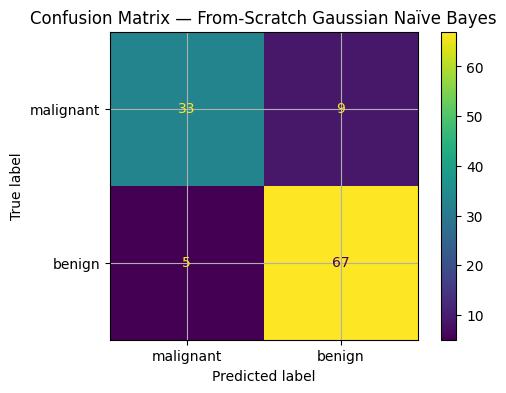

In [92]:
gnb = GaussianNaiveBayes(var_smoothing=1e-9)
gnb.fit(X_train, y_train)

# 4. Predictions
y_pred = gnb.predict(X_test)

# 5. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=cancer.target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(values_format="d")
plt.title("Confusion Matrix — From-Scratch Gaussian Naïve Bayes")
plt.show()